# heart failure dataset eda and model comparison

this notebook is for report evidence.

it covers:
- data loading and schema checks
- exploratory data analysis with visualizations
- two-model comparison on the same split
- confusion matrices and roc curves
- reading saved training metrics from artifacts


In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("data/heart.csv")
ARTIFACTS_DIR = Path("artifacts")

if not DATA_PATH.exists():
    raise FileNotFoundError("place the dataset at data/heart.csv")

df = pd.read_csv(DATA_PATH)
sns.set_theme(style="whitegrid")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
rename_map = {
    "ChestPainType": "chest pain type",
    "RestingBP": "resting bp s",
    "FastingBS": "fasting bs",
    "RestingECG": "resting ecg",
    "MaxHR": "max hr",
    "ExerciseAngina": "exercise angina",
    "ST_Slope": "st slope",
    "HeartDisease": "heartdisease",
    "Age": "age",
    "Sex": "sex",
    "Cholesterol": "cholesterol",
    "Oldpeak": "oldpeak",
}

df = df.rename(columns=rename_map)

print("shape:", df.shape)
print("\ncolumn types:")
print(df.dtypes)
print("\nmissing values:")
print(df.isna().sum())

shape: (918, 12)

column types:
age                  int64
sex                 object
chest pain type     object
resting bp s         int64
cholesterol          int64
fasting bs           int64
resting ecg         object
max hr               int64
exercise angina     object
oldpeak            float64
st slope            object
heartdisease         int64
dtype: object

missing values:
age                0
sex                0
chest pain type    0
resting bp s       0
cholesterol        0
fasting bs         0
resting ecg        0
max hr             0
exercise angina    0
oldpeak            0
st slope           0
heartdisease       0
dtype: int64


In [3]:
target_counts = df["heartdisease"].value_counts().sort_index()
target_ratio = df["heartdisease"].value_counts(normalize=True).sort_index().round(4)

print("target counts:")
print(target_counts)
print("\ntarget ratio:")
print(target_ratio)

target_counts

target counts:
heartdisease
0    410
1    508
Name: count, dtype: int64

target ratio:
heartdisease
0    0.4466
1    0.5534
Name: proportion, dtype: float64


heartdisease
0    410
1    508
Name: count, dtype: int64

In [4]:
numeric_cols = ["age", "resting bp s", "cholesterol", "max hr", "oldpeak"]

print("numeric summary:")
print(df[numeric_cols].describe().T)

print("\nheart disease rate by sex:")
print(df.groupby("sex")["heartdisease"].mean().round(4))

print("\nheart disease rate by chest pain type:")
print(df.groupby("chest pain type")["heartdisease"].mean().round(4).sort_values(ascending=False))

numeric summary:
              count        mean         std   min     25%    50%    75%    max
age           918.0   53.510893    9.432617  28.0   47.00   54.0   60.0   77.0
resting bp s  918.0  132.396514   18.514154   0.0  120.00  130.0  140.0  200.0
cholesterol   918.0  198.799564  109.384145   0.0  173.25  223.0  267.0  603.0
max hr        918.0  136.809368   25.460334  60.0  120.00  138.0  156.0  202.0
oldpeak       918.0    0.887364    1.066570  -2.6    0.00    0.6    1.5    6.2

heart disease rate by sex:
sex
F    0.2591
M    0.6317
Name: heartdisease, dtype: float64

heart disease rate by chest pain type:
chest pain type
ASY    0.7903
TA     0.4348
NAP    0.3547
ATA    0.1387
Name: heartdisease, dtype: float64


In [5]:
metrics_path = ARTIFACTS_DIR / "metrics.json"

if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    print("selected model:", metrics["selected_model"])
    pd.DataFrame(metrics["metrics"]).T
else:
    print("metrics file not found. run training/train.py first.")

selected model: random_forest


## visual exploratory analysis

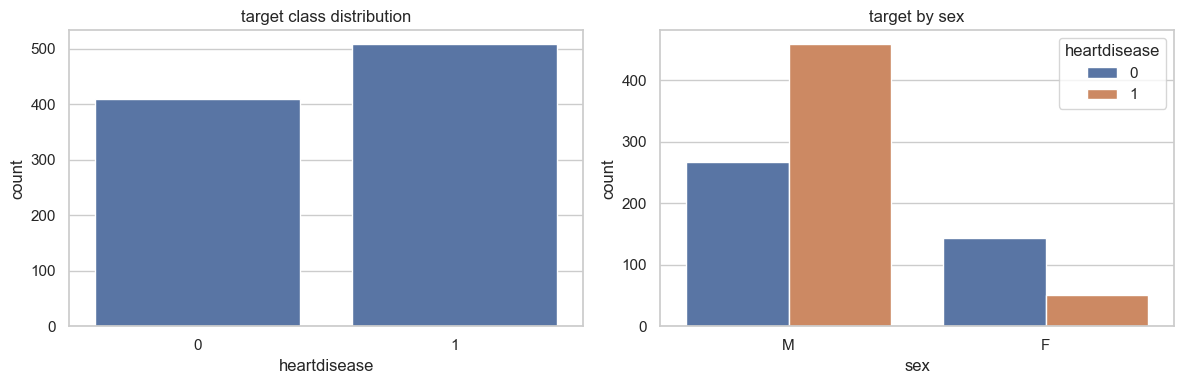

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="heartdisease", ax=axes[0])
axes[0].set_title("target class distribution")
axes[0].set_xlabel("heartdisease")

sns.countplot(data=df, x="sex", hue="heartdisease", ax=axes[1])
axes[1].set_title("target by sex")
axes[1].set_xlabel("sex")

plt.tight_layout()
plt.show()

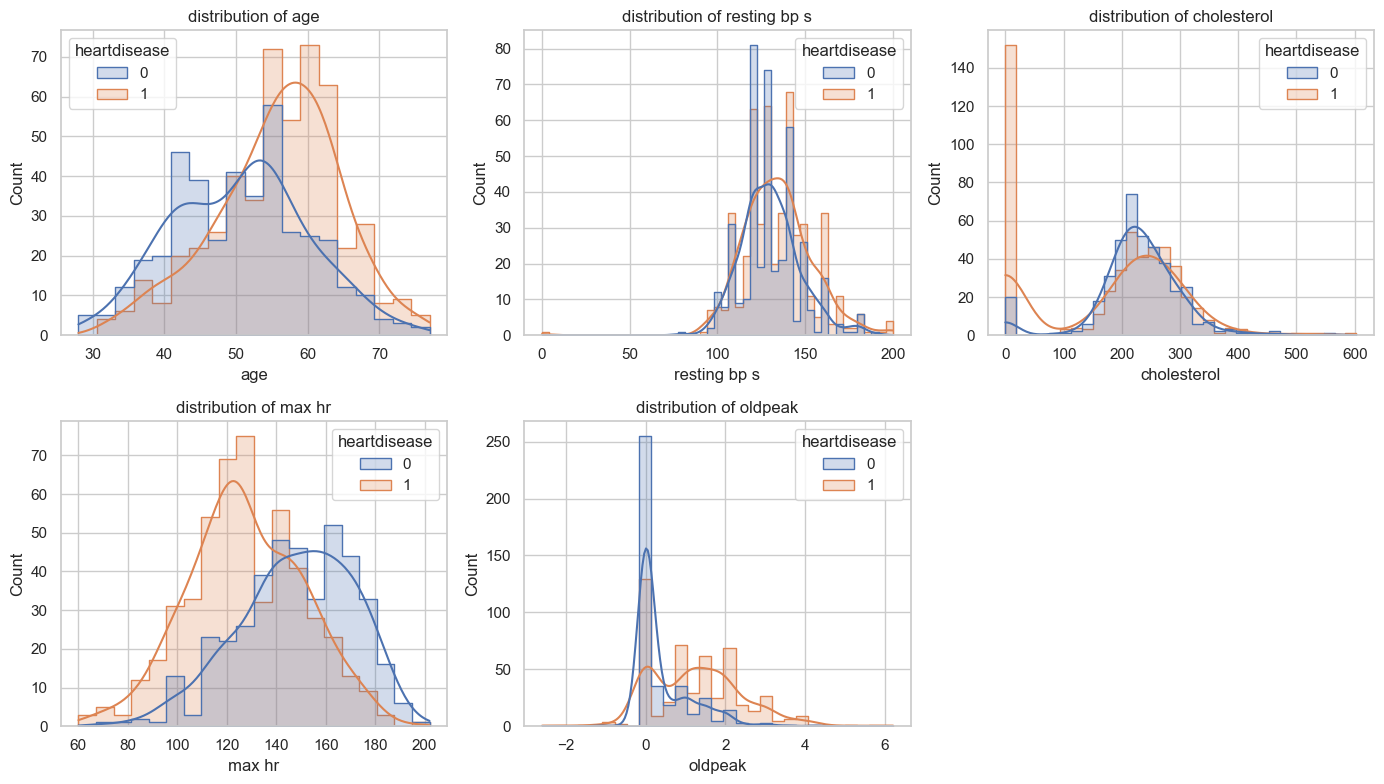

In [7]:
plot_cols = ["age", "resting bp s", "cholesterol", "max hr", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for index, col in enumerate(plot_cols):
    sns.histplot(data=df, x=col, hue="heartdisease", kde=True, ax=axes[index], element="step")
    axes[index].set_title(f"distribution of {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

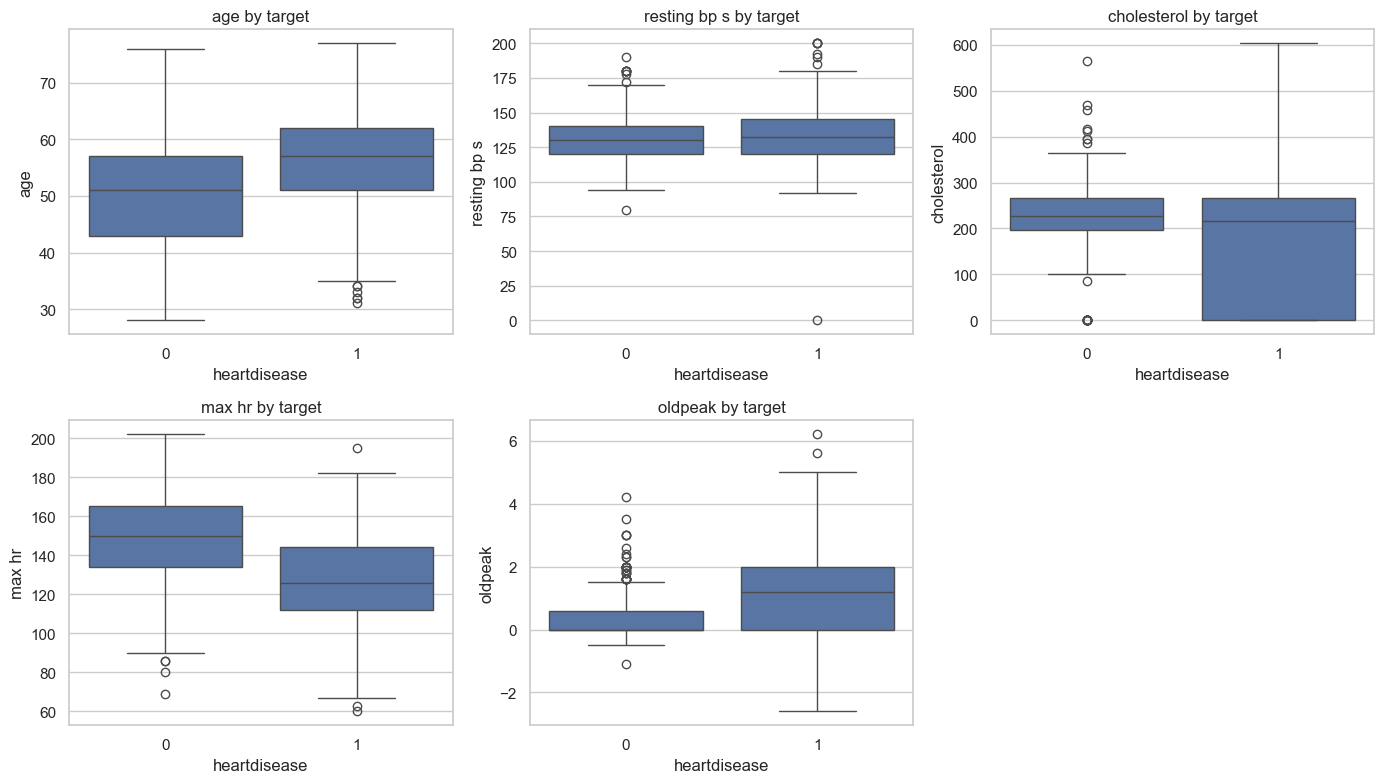

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for index, col in enumerate(plot_cols):
    sns.boxplot(data=df, x="heartdisease", y=col, ax=axes[index])
    axes[index].set_title(f"{col} by target")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

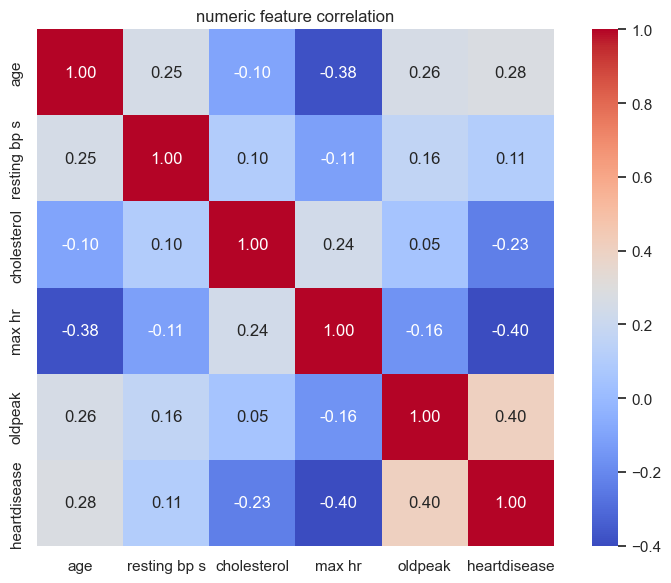

In [9]:
corr = df[["age", "resting bp s", "cholesterol", "max hr", "oldpeak", "heartdisease"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("numeric feature correlation")
plt.tight_layout()
plt.show()

## two-model comparison (same split)

In [10]:
y = df["heartdisease"].astype(int)
X = df.drop(columns=["heartdisease"])

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

models = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(n_estimators=400, random_state=42),
}

eval_rows = []
predictions = {}
probabilities = {}

for model_name, model in models.items():
    model.fit(X_train_t, y_train)
    pred = model.predict(X_test_t)
    prob = model.predict_proba(X_test_t)[:, 1]

    predictions[model_name] = pred
    probabilities[model_name] = prob

    eval_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, prob),
        }
    )

results_df = pd.DataFrame(eval_rows).set_index("model").round(4)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logistic_regression,0.8967,0.8879,0.9314,0.9091,0.9296
random_forest,0.9076,0.8972,0.9412,0.9187,0.9316


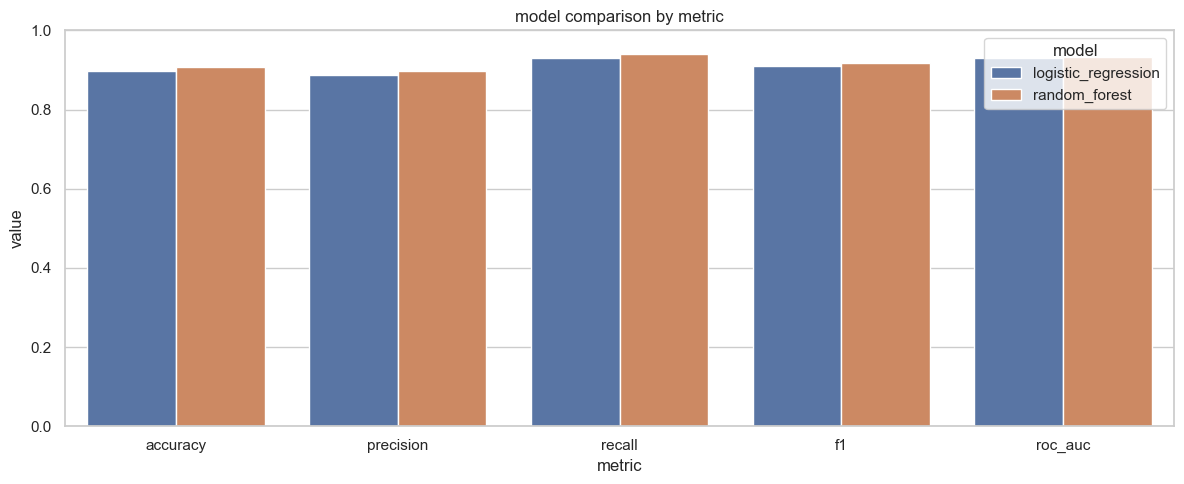

In [11]:
metric_plot_df = results_df.reset_index().melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(12, 5))
sns.barplot(data=metric_plot_df, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("model comparison by metric")
plt.tight_layout()
plt.show()

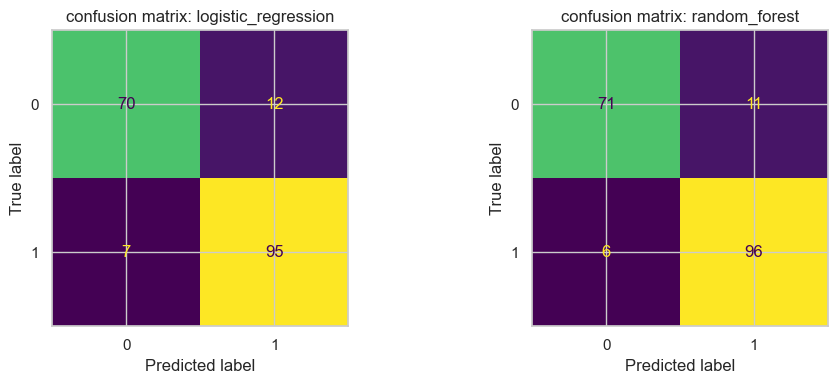

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for index, model_name in enumerate(models.keys()):
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[model_name], ax=axes[index], colorbar=False)
    axes[index].set_title(f"confusion matrix: {model_name}")

plt.tight_layout()
plt.show()

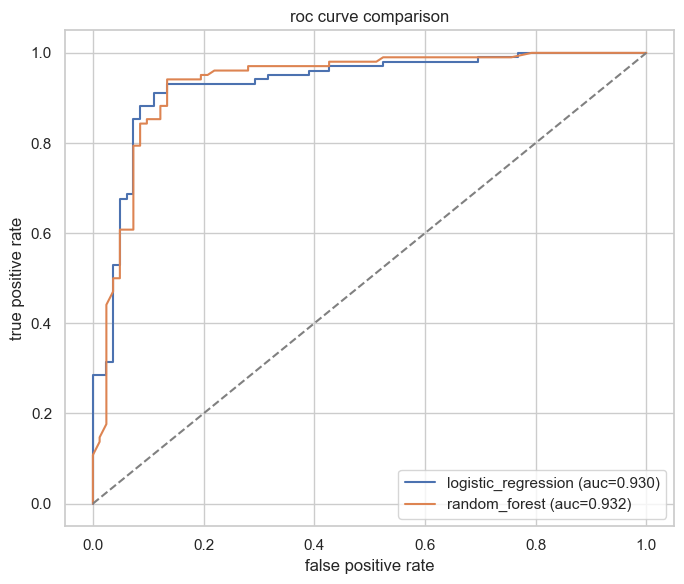

In [13]:
plt.figure(figsize=(7, 6))

for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    auc_value = roc_auc_score(y_test, probabilities[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (auc={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc curve comparison")
plt.legend()
plt.tight_layout()
plt.show()

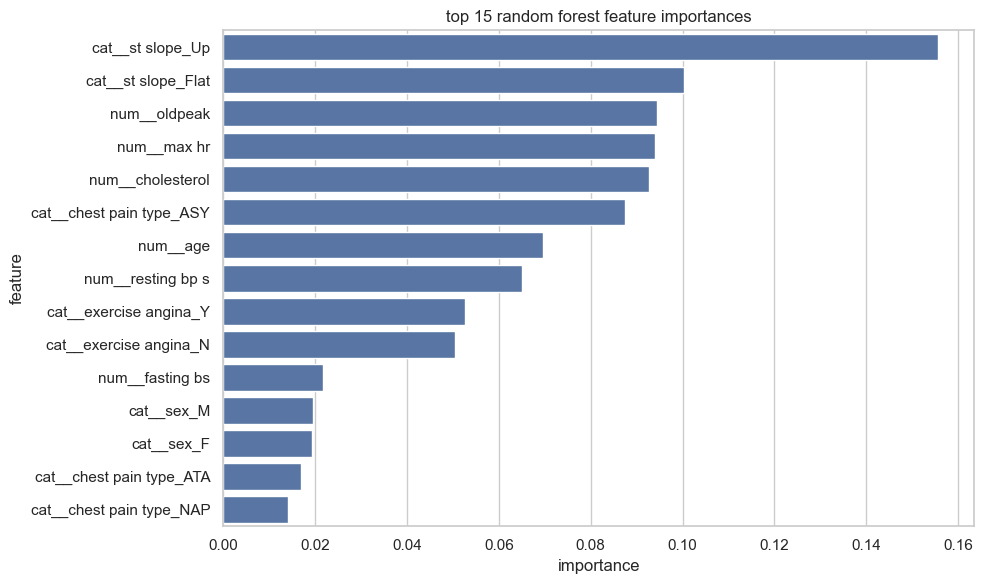

,feature,importance
19,cat__st slope_Up,0.155688
18,cat__st slope_Flat,0.100301
5,num__oldpeak,0.094489
4,num__max hr,0.094040
2,num__cholesterol,0.092755
8,cat__chest pain type_ASY,0.087483
0,num__age,0.069672
1,num__resting bp s,0.065021
16,cat__exercise angina_Y,0.052592
15,cat__exercise angina_N,0.050530


In [14]:
rf_model = models["random_forest"]
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": rf_model.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("top 15 random forest feature importances")
plt.tight_layout()
plt.show()

importance_df.head(15)